In [25]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph,START,END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from typing import Annotated
from langchain_experimental.utilities import PythonREPL
from langchain_community.tools import DuckDuckGoSearchRun

In [26]:
load_dotenv()
openai_model=ChatOpenAI(model="gpt-4o-mini")
openai_model.invoke("hi")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f6834ac66f', 'id': 'chatcmpl-Df7QSs850Hp1EtA1jV8vkmPqPtzpc', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2253-97db-7ab0-bc87-e9802cb03ff4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [27]:
search_tool=DuckDuckGoSearchRun()
search_tool.invoke("what is a gdp of india?")

"2 days ago -India has a developing mixed economy with a notable public sector in strategic sectors. It is the world's sixth-largest economy by nominal GDP and the third-largest by purchasing power parity (PPP) as of April 2026. On a per capita income basis, the is nation ranked 149th by nominal GDP and 119th by PPP-adjusted GDP as 2026. 3 weeks ago -These are lists of Indian states and union territories by their nominal gross state domestic product (GSDP). GSDP is the sum of all value added by industries within each state or union territory and serves as a counterpart to the national gross domestic product (GDP). 5 days ago -Manufacturing accounts for 15 percent of GDP, construction for another 8 percent and mining, quarrying, electricity, gas and water supply for the remaining 5 percent. ... The Indian real gross domestic product expanded by 7.8% from the previous year in the December quarter of 2025, inching down from the upwardly revised, six-quarter high of 8.4% in the earlier per

In [28]:
repl=PythonREPL()

code = """
x = 5
y = x * 2
print(y)
"""

repl.run(code)

'10\n'

In [29]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [30]:
def make_system_prompt(instruction:str)->str:
    return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [31]:
make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    )

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [32]:
def get_next_node(last_message:BaseMessage, goto:str):
    if "FINAL ANSWER" in last_message.content:
        # Any agent decided the work is done
        return END
    return goto

In [33]:
from langchain.agents import create_agent

agent = create_agent(
    model=openai_model,
    tools=[search_tool],
    prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    )
)

TypeError: create_agent() got an unexpected keyword argument 'prompt'

In [27]:
resaerch_agent = create_react_agent(
    openai_model,
    tools=[search_tool],
    prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    )
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6752\872014656.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  resaerch_agent = create_react_agent(


In [28]:
chart_agent = create_react_agent(
    openai_model,
    tools=[search_tool],
    prompt=make_system_prompt(
     "You can only generate charts. You are working with a researcher colleague."
),
)


C:\Users\Admin\AppData\Local\Temp\ipykernel_6752\474553150.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


In [29]:
state={"message":["hi","hello"]}
state["message"][-1]

'hello'

In [30]:
def research_node(state:MessagesState)->Command[Literal["chart_generator", END]]:
    
    result = research_agent.invoke(state)
    
    goto = get_next_node(result["messages"][-1], "chart_generator")
    
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")
    
    return Command(update={"messages": result["messages"]},goto=goto)

In [31]:
def chart_node(state:MessagesState)-> Command[Literal["researcher", END]]:
    
    result = chart_agent.invoke(state)
    
    goto = get_next_node(result["messages"][-1], "researcher")
    
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    
    return Command(update={"messages": result["messages"]},goto=goto)


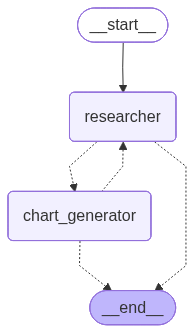

In [32]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

display(Image(app.get_graph().draw_mermaid_png()))

In [33]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})

NameError: name 'research_agent' is not defined